# 보스턴 집값 데이터 회귀분석

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns

In [3]:
data = pd.read_csv('https://raw.githubusercontent.com/haram4th/ADsP/main/01%EB%B3%B4%EC%8A%A4%ED%84%B4%EC%A7%91%EA%B0%92%EB%8D%B0%EC%9D%B4%ED%84%B0.csv')
data

,범죄율,"25,000평방피트초과",비소매상업지역비율,찰스강경계,농축 일산화질소,가구당평균방수,1940년이전건축비율,직업센터접근성,도로접근성,재산세율,학생/교사비율,흑인비율,하위계층비율,주택가격
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48,22.0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   범죄율           506 non-null    float64
 1   25,000평방피트초과  506 non-null    float64
 2   비소매상업지역비율     506 non-null    float64
 3   찰스강경계         506 non-null    int64  
 4   농축 일산화질소      506 non-null    float64
 5   가구당평균방수       506 non-null    float64
 6   1940년이전건축비율   506 non-null    float64
 7   직업센터접근성       506 non-null    float64
 8   도로접근성         506 non-null    int64  
 9   재산세율          506 non-null    float64
 10  학생/교사비율       506 non-null    float64
 11  흑인비율          506 non-null    float64
 12  하위계층비율        506 non-null    float64
 13  주택가격          506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [5]:
data.describe()

,범죄율,"25,000평방피트초과",비소매상업지역비율,찰스강경계,농축 일산화질소,가구당평균방수,1940년이전건축비율,직업센터접근성,도로접근성,재산세율,학생/교사비율,흑인비율,하위계층비율,주택가격
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [6]:
data.columns

Index(['범죄율', '25,000평방피트초과', '비소매상업지역비율', '찰스강경계', '농축 일산화질소', '가구당평균방수',
       '1940년이전건축비율', '직업센터접근성', '도로접근성', '재산세율', '학생/교사비율', '흑인비율', '하위계층비율',
       '주택가격'],
      dtype='object')

<Axes: >

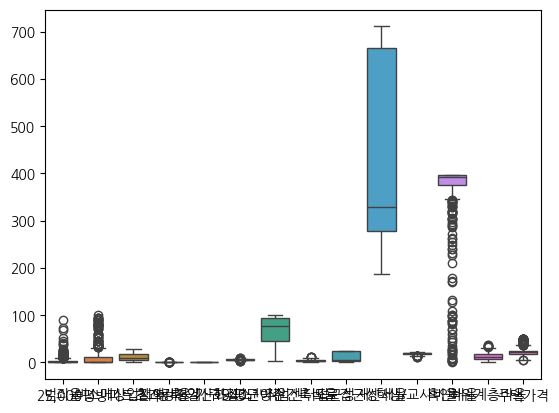

In [7]:
sns.boxplot(data)

<Axes: >

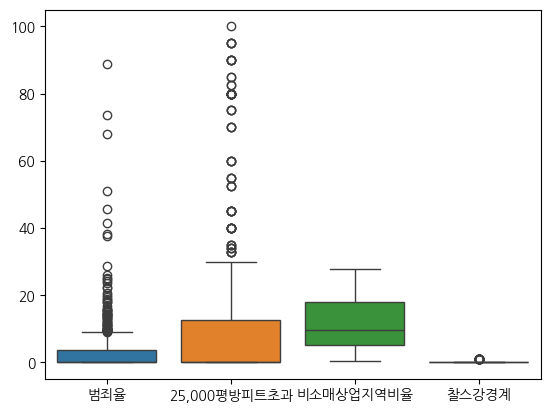

In [8]:
sns.boxplot(data[['범죄율', '25,000평방피트초과', '비소매상업지역비율', '찰스강경계']])

<Axes: >

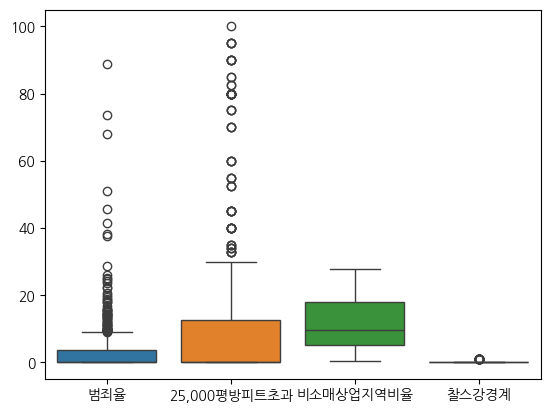

In [9]:
sns.boxplot(data[['범죄율', '25,000평방피트초과', '비소매상업지역비율', '찰스강경계']])

<Axes: >

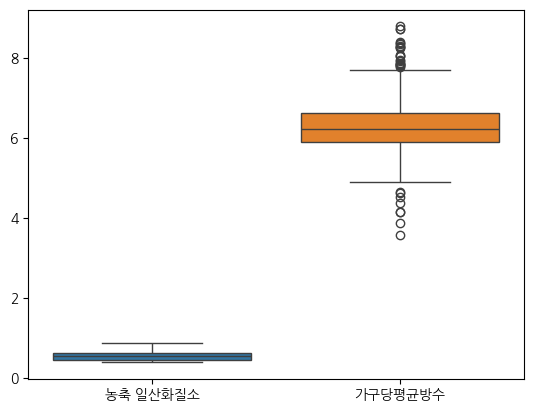

In [10]:
sns.boxplot(data[['농축 일산화질소', '가구당평균방수']])

<Axes: >

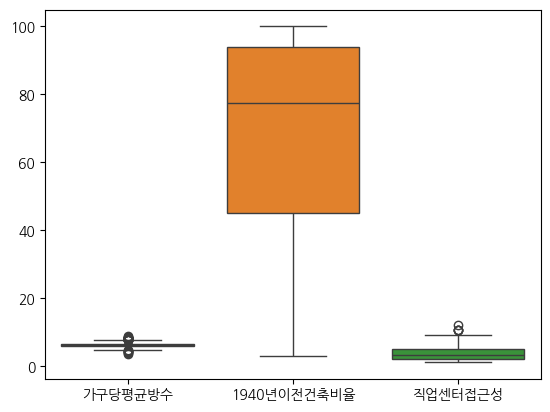

In [12]:
sns.boxplot(data[['가구당평균방수',
       '1940년이전건축비율', '직업센터접근성']])

In [14]:
sns.boxplot(data[['학생/교사비율', '흑인비율', '하위계층비율']])

<Axes: >

In [21]:
sns.boxplot(data['학생/교사비율'])

<Axes: ylabel='학생/교사비율'>

In [13]:
data.corr(method='spearman')

,범죄율,"25,000평방피트초과",비소매상업지역비율,찰스강경계,농축 일산화질소,가구당평균방수,1940년이전건축비율,직업센터접근성,도로접근성,재산세율,학생/교사비율,흑인비율,하위계층비율,주택가격
범죄율,1.000000,-0.571660,0.735524,0.041537,0.821465,-0.309116,0.704140,-0.744986,0.727807,0.729045,0.465283,-0.360555,0.634760,-0.558891
"25,000평방피트초과",-0.571660,1.000000,-0.642811,-0.041937,-0.634828,0.361074,-0.544423,0.614627,-0.278767,-0.371394,-0.448475,0.163135,-0.490074,0.438179
비소매상업지역비율,0.735524,-0.642811,1.000000,0.089841,0.791189,-0.415301,0.679487,-0.757080,0.455507,0.664361,0.433710,-0.285840,0.638747,-0.578255
찰스강경계,0.041537,-0.041937,0.089841,1.000000,0.068426,0.058813,0.067792,-0.080248,0.024579,-0.044486,-0.136065,-0.039810,-0.050575,0.140612
농축 일산화질소,0.821465,-0.634828,0.791189,0.068426,1.000000,-0.310344,0.795153,-0.880015,0.586429,0.649527,0.391309,-0.296662,0.636828,-0.562609
가구당평균방수,-0.309116,0.361074,-0.415301,0.058813,-0.310344,1.000000,-0.278082,0.263168,-0.107492,-0.271898,-0.312923,0.053660,-0.640832,0.633576
1940년이전건축비율,0.704140,-0.544423,0.679487,0.067792,0.795153,-0.278082,1.000000,-0.801610,0.417983,0.526366,0.355384,-0.228022,0.657071,-0.547562
직업센터접근성,-0.744986,0.614627,-0.757080,-0.080248,-0.880015,0.263168,-0.801610,1.000000,-0.495806,-0.574336,-0.322041,0.249595,-0.564262,0.445857
도로접근성,0.727807,-0.278767,0.455507,0.024579,0.586429,-0.107492,0.417983,-0.495806,1.000000,0.704876,0.318330,-0.282533,0.394322,-0.346776
재산세율,0.729045,-0.371394,0.664361,-0.044486,0.649527,-0.271898,0.526366,-0.574336,0.704876,1.000000,0.453345,-0.329843,0.534423,-0.562411


<Axes: >

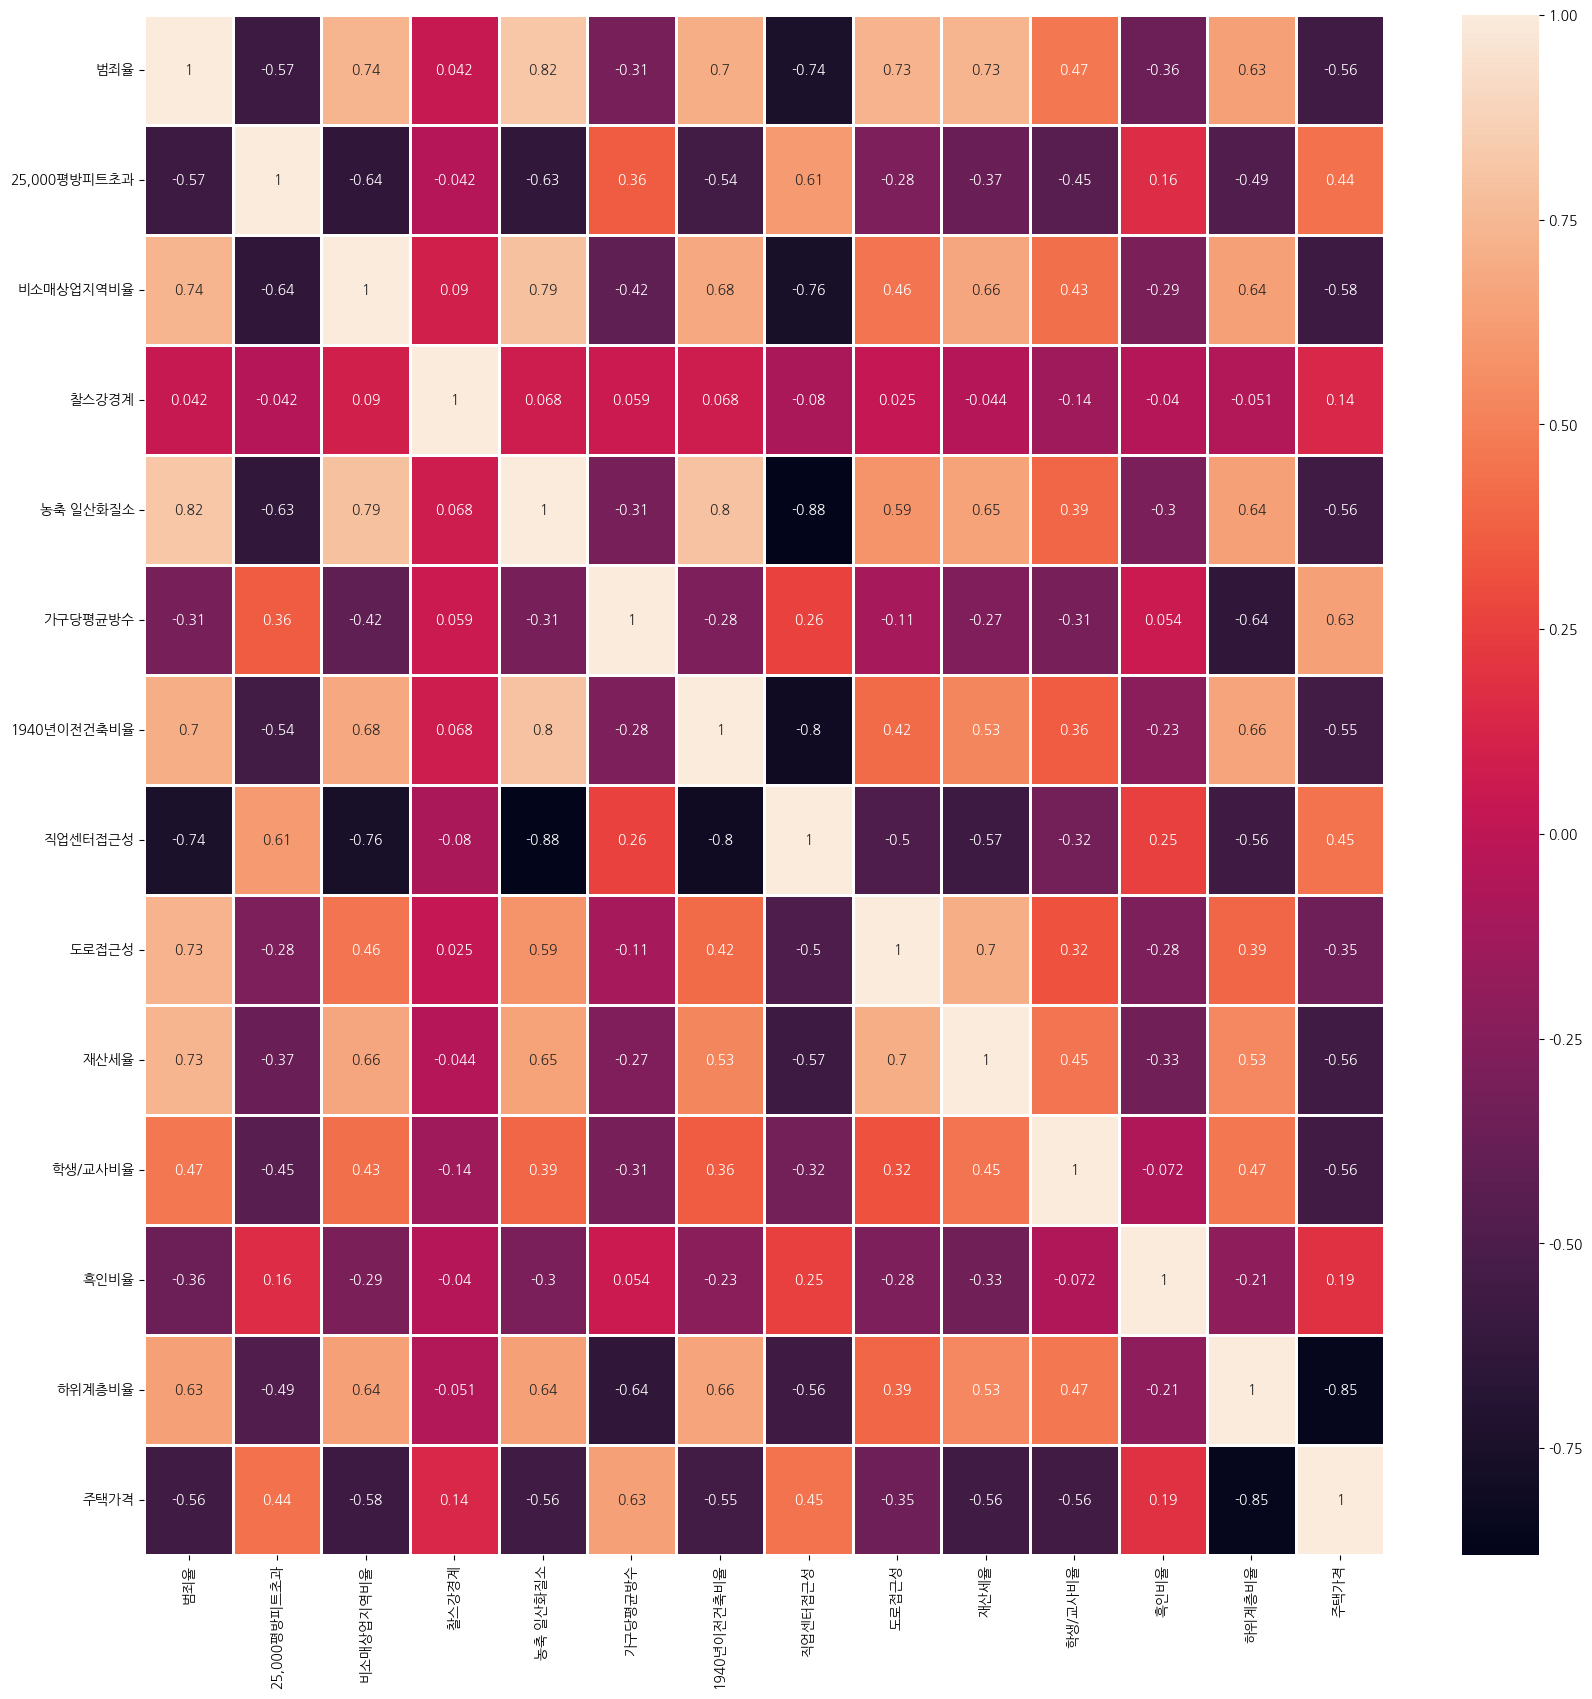

In [16]:
plt.figure(figsize=(20, 20))
sns.heatmap(data.corr(method='spearman'), annot=True, linewidth=1, font_size=)

In [17]:
X = data.drop('주택가격', axis=1)
y = data['주택가격']

In [18]:
from sklearn.model_selection import train_test_split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

In [21]:
X_train2 = X_train.copy()
X_test2 = X_test.copy()

스케일 맞추기

In [22]:
from sklearn.preprocessing import RobustScaler

In [24]:
rs = RobustScaler()
rs.fit(X_train)
rs_X_train = rs.transform(X_train)
rs_X_test = rs.transform(X_test)
rs_X_train = pd.DataFrame(rs_X_train, columns=X_train.columns, index=X_train.index)
rs_X_test = pd.DataFrame(rs_X_test, columns=X_test.columns, index=X_test.index)

In [25]:
rs_X_train

,범죄율,"25,000평방피트초과",비소매상업지역비율,찰스강경계,농축 일산화질소,가구당평균방수,1940년이전건축비율,직업센터접근성,도로접근성,재산세율,학생/교사비율,흑인비율,하위계층비율
301,-0.060267,3.626667,-0.293755,0.0,-0.557377,0.539604,-0.756456,0.711464,0.10,-0.002597,-0.818182,0.185614,-0.175908
392,3.139437,0.000000,0.632228,0.0,0.901639,-1.658416,0.389873,-0.483524,0.95,0.872727,0.424242,0.238385,1.591915
375,5.365765,0.000000,0.632228,0.0,0.743169,1.562235,0.408101,-0.629201,0.95,0.872727,0.424242,0.238385,0.254575
183,-0.042329,0.000000,-0.573631,0.0,-0.256831,0.501414,0.361519,-0.137714,-0.10,-0.355844,-0.303030,0.238385,-0.593281
84,-0.056048,0.000000,-0.417116,0.0,-0.469945,0.255304,-0.602532,0.482754,-0.10,-0.215584,-0.090909,0.238385,-0.162797
...,...,...,...,...,...,...,...,...,...,...,...,...,...
347,-0.064888,9.066667,-0.443331,0.0,-0.579235,0.434936,-1.013671,1.688723,-0.05,0.054545,-0.272727,0.033268,-0.518984
185,-0.053309,0.000000,-0.573631,0.0,-0.256831,-0.078501,-0.181266,0.001220,-0.10,-0.355844,-0.303030,-0.210852,0.222890
197,-0.057137,8.533333,-0.646106,0.0,-0.715847,1.270863,-0.833418,1.294974,-0.15,-0.002597,-1.878788,-1.715957,-0.273149
35,-0.052283,0.000000,-0.303778,0.0,-0.196721,-0.389675,-0.193418,0.027100,0.00,-0.132468,0.121212,0.238385,-0.156241


In [26]:
rs_X_test

,범죄율,"25,000평방피트초과",비소매상업지역비율,찰스강경계,농축 일산화질소,가구당평균방수,1940년이전건축비율,직업센터접근성,도로접근성,재산세율,학생/교사비율,흑인비율,하위계층비율
164,0.551533,0.0,0.746338,0.0,0.382514,-0.501414,0.284557,-0.274176,0.00,0.189610,-1.242424,0.156246,0.057908
144,0.700500,0.0,0.746338,0.0,1.836066,-1.846535,0.406076,-0.619697,0.00,0.189610,-1.242424,0.238385,1.986343
316,0.018156,0.0,0.000000,0.0,0.049180,-0.416549,0.110380,0.232049,-0.05,-0.067532,-0.121212,-0.046117,0.788856
386,6.692131,0.0,0.632228,0.0,0.901639,-2.201556,0.450633,-0.580749,0.95,0.872727,0.424242,0.238385,1.875990
450,1.792147,0.0,0.632228,0.0,0.972678,0.764498,0.300759,-0.305771,0.95,0.872727,0.424242,-17.959619,0.691614
...,...,...,...,...,...,...,...,...,...,...,...,...,...
499,-0.020775,0.0,-0.016191,0.0,0.273224,-0.904526,-0.086076,-0.281272,0.05,0.158442,0.121212,0.186532,0.435946
430,2.284031,0.0,0.632228,0.0,0.267760,0.197313,0.169114,-0.392753,0.95,0.872727,0.424242,-14.145004,0.713466
485,0.948306,0.0,0.632228,0.0,0.262295,0.146393,-0.523544,0.229834,0.95,0.872727,0.424242,-0.141562,-0.057908
99,-0.051055,0.0,-0.540478,0.0,-0.491803,1.707921,-0.308861,0.070414,-0.15,-0.140260,-0.242424,0.238385,-0.537558


# 선형회귀분석

In [27]:
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [28]:
# 상수항 추가
rs_X_train_const = sm.add_constant(rs_X_train)
rs_X_test_const = sm.add_constant(rs_X_test)

In [31]:
rs_X_train_const.head(2)

,const,범죄율,"25,000평방피트초과",비소매상업지역비율,찰스강경계,농축 일산화질소,가구당평균방수,1940년이전건축비율,직업센터접근성,도로접근성,재산세율,학생/교사비율,흑인비율,하위계층비율
301,1.0,-0.060267,3.626667,-0.293755,0.0,-0.557377,0.539604,-0.756456,0.711464,0.10,-0.002597,-0.818182,0.185614,-0.175908
392,1.0,3.139437,0.000000,0.632228,0.0,0.901639,-1.658416,0.389873,-0.483524,0.95,0.872727,0.424242,0.238385,1.591915


In [32]:
rs_X_test_const.head(2)

,const,범죄율,"25,000평방피트초과",비소매상업지역비율,찰스강경계,농축 일산화질소,가구당평균방수,1940년이전건축비율,직업센터접근성,도로접근성,재산세율,학생/교사비율,흑인비율,하위계층비율
164,1.0,0.551533,0.0,0.746338,0.0,0.382514,-0.501414,0.284557,-0.274176,0.0,0.18961,-1.242424,0.156246,0.057908
144,1.0,0.700500,0.0,0.746338,0.0,1.836066,-1.846535,0.406076,-0.619697,0.0,0.18961,-1.242424,0.238385,1.986343


In [39]:
ols = sm.OLS(y_train, rs_X_train_const).fit()
pred = ols.predict(rs_X_test_const)
print("MAE: ", mean_absolute_error(y_test, pred))
print("MSE: ", mean_squared_error(y_test, pred))
print("RMSE: ", np.sqrt(mean_squared_error(y_test, pred)))
print("R2L ", r2_score(y_test, pred))

MAE:  3.1715019280923955
MSE:  23.701453532722528
RMSE:  4.868413862103604
R2L  0.72198987703056


In [40]:
print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:                   주택가격   R-squared:                       0.745
Model:                            OLS   Adj. R-squared:                  0.735
Method:                 Least Squares   F-statistic:                     76.49
Date:                Thu, 08 May 2025   Prob (F-statistic):           1.63e-92
Time:                        14:41:49   Log-Likelihood:                -1044.5
No. Observations:                 354   AIC:                             2117.
Df Residuals:                     340   BIC:                             2171.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           23.1005      0.396     58.290   

In [41]:
result = pd.DataFrame(dict(y_test=y_test, pred=pred))
result

,y_test,pred
164,22.7,24.161252
144,11.8,8.592692
316,17.8,17.198791
386,10.5,5.534262
450,13.4,16.293472
...,...,...
499,17.5,18.201057
430,14.5,17.668459
485,21.2,21.672877
99,33.2,32.147813


In [42]:
result['잔차'] = result['y_test'] - result['pred']
result['잔차제곱'] = result['잔차'] **2
result['MSE'] = result['잔차제곱'].mean()
result['RMSE'] = result['MSE'].apply(np.sqrt)
result

,y_test,pred,잔차,잔차제곱,MSE,RMSE
164,22.7,24.161252,-1.461252,2.135259,23.701454,4.868414
144,11.8,8.592692,3.207308,10.286825,23.701454,4.868414
316,17.8,17.198791,0.601209,0.361452,23.701454,4.868414
386,10.5,5.534262,4.965738,24.658555,23.701454,4.868414
450,13.4,16.293472,-2.893472,8.372181,23.701454,4.868414
...,...,...,...,...,...,...
499,17.5,18.201057,-0.701057,0.491481,23.701454,4.868414
430,14.5,17.668459,-3.168459,10.039133,23.701454,4.868414
485,21.2,21.672877,-0.472877,0.223612,23.701454,4.868414
99,33.2,32.147813,1.052187,1.107097,23.701454,4.868414


# 최적회귀 구하기(단계적 변수 선택법)
* 1) 전진선택법
* 2) 후진제거법

In [43]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression

In [44]:
model = LinearRegression()

* 전진선택법으로 분석

In [48]:
sfs_fw = SequentialFeatureSelector(estimator=model, direction='forward',
                                 scoring='r2', cv=5, n_jobs=4)
sfs_fw.fit(rs_X_train_const, y_train)
# print(sfs_fw.get_support())
selected_cols = rs_X_train_const.columns[sfs_fw.get_support()]
print("전진선택법으로 선택된 컬럼: ", list(selected_cols))

전진선택법으로 선택된 컬럼:  ['25,000평방피트초과', '찰스강경계', '농축 일산화질소', '가구당평균방수', '직업센터접근성', '학생/교사비율', '하위계층비율']


In [50]:
print("원래 컬럼수: ", len(rs_X_train_const.columns))
print("selected_cols: ", len(selected_cols))

원래 컬럼수:  14
selected_cols:  7


In [51]:
selected_cols

Index(['25,000평방피트초과', '찰스강경계', '농축 일산화질소', '가구당평균방수', '직업센터접근성', '학생/교사비율',
       '하위계층비율'],
      dtype='object')

In [52]:
fw_X_train = rs_X_train_const[['const', '범죄율', '찰스강경계', '농축 일산화질소', '가구당평균방수', '직업센터접근성', '학생/교사비율',
       '하위계층비율']]
fw_X_test = rs_X_test_const[['const', '범죄율', '찰스강경계', '농축 일산화질소', '가구당평균방수', '직업센터접근성', '학생/교사비율',
       '하위계층비율']]

In [53]:
ols2 = sm.OLS(y_train, fw_X_train).fit()
pred = ols2.predict(fw_X_test)
print("MAE: ", mean_absolute_error(y_test, pred))
print("MSE: ", mean_squared_error(y_test, pred))
print("RMSE: ", np.sqrt(mean_squared_error(y_test, pred)))
print("R2L ", r2_score(y_test, pred))

MAE:  3.2804570022601935
MSE:  25.306754685408226
RMSE:  5.030581943016953
R2L  0.7031602314037642


In [58]:
print(ols2.summary())

                            OLS Regression Results                            
Dep. Variable:                   주택가격   R-squared:                       0.723
Model:                            OLS   Adj. R-squared:                  0.717
Method:                 Least Squares   F-statistic:                     128.9
Date:                Thu, 08 May 2025   Prob (F-statistic):           2.17e-92
Time:                        15:11:28   Log-Likelihood:                -1059.5
No. Observations:                 354   AIC:                             2135.
Df Residuals:                     346   BIC:                             2166.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         23.3140      0.357     65.238      0.0

# 후진제거법

In [59]:
sfs_bw = SequentialFeatureSelector(estimator=model, direction='backward',
                                 scoring='r2', cv=5, n_jobs=4)
sfs_bw.fit(rs_X_train_const, y_train)
# print(sfs_fw.get_support())
selected_cols = rs_X_train_const.columns[sfs_bw.get_support()]
print("후진선택법으로 선택된 컬럼: ", list(selected_cols))
print("원래 컬럼수: ", len(rs_X_train_const.columns))
print("selected_cols: ", len(selected_cols))

후진선택법으로 선택된 컬럼:  ['25,000평방피트초과', '가구당평균방수', '직업센터접근성', '도로접근성', '재산세율', '학생/교사비율', '하위계층비율']
원래 컬럼수:  14
selected_cols:  7


In [60]:
bw_X_train = rs_X_train_const[['const', '범죄율', '농축 일산화질소', '가구당평균방수', '직업센터접근성', '도로접근성', '재산세율', '학생/교사비율', '하위계층비율']]
bw_X_test = rs_X_test_const[['const', '범죄율', '농축 일산화질소', '가구당평균방수', '직업센터접근성', '도로접근성', '재산세율', '학생/교사비율', '하위계층비율']]

In [61]:
ols3 = sm.OLS(y_train, bw_X_train).fit()
pred = ols3.predict(bw_X_test)
print("MAE: ", mean_absolute_error(y_test, pred))
print("MSE: ", mean_squared_error(y_test, pred))
print("RMSE: ", np.sqrt(mean_squared_error(y_test, pred)))
print("R2L ", r2_score(y_test, pred))

MAE:  3.2976229045516643
MSE:  24.437504897419295
RMSE:  4.943430478667551
R2L  0.713356240695613


In [62]:
print(ols3.summary())

                            OLS Regression Results                            
Dep. Variable:                   주택가격   R-squared:                       0.724
Model:                            OLS   Adj. R-squared:                  0.717
Method:                 Least Squares   F-statistic:                     113.0
Date:                Thu, 08 May 2025   Prob (F-statistic):           1.34e-91
Time:                        15:20:40   Log-Likelihood:                -1058.8
No. Observations:                 354   AIC:                             2136.
Df Residuals:                     345   BIC:                             2170.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         23.4135      0.374     62.607      0.0

# 정규화를 통한 선형회귀 변수 선택법
## 1) Lasso 회귀(L1규제)
* 가중치의 절대값의 합을 최소화
* 일부 가중치를 0으로 만들어서 변수를 무력화
* 변수를 선택하는 효과
* 불필요한 변수 제거

## 2) Ridge 회귀(L2규제)
* 가중치의 제곱합을 최소화
* 계수를 0에 가깝게 만들지만 제거는 하지 않음
* 다중공선성 해결에 효과적

## 3) Elastic Net(혼합 규제, L1 + L2)
* L1 규제와 L2 규제를 결합한 모델
* Lasso와 Ridge의 장점을 모두 활용
* 변수 간 상관관계가 높을 때 효과적

# 정규화 회귀를 사용하는 이유: 과적합 방지, 범용성 향상

# 라쏘(Lasso, L1 제약, 절대값, 변수제외)

In [63]:
from sklearn.linear_model import Lasso

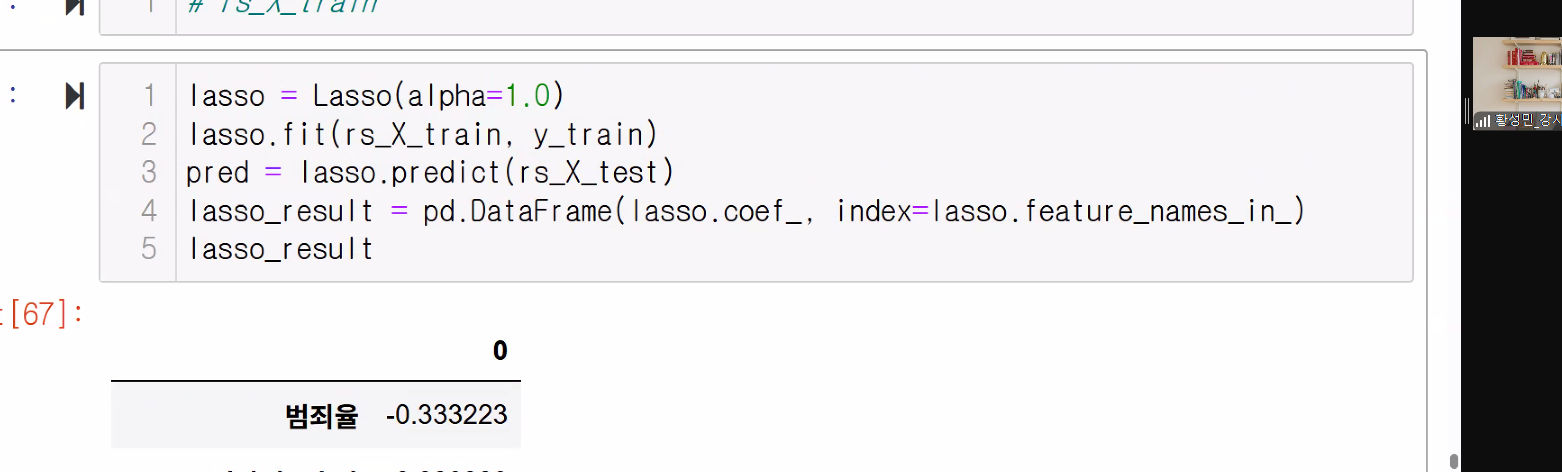

In [67]:
lasso = Lasso(alpha=1.0)
lasso.fit(rs_X_train, y_train)
pred = lasso.predict(rs_X_test)
lasso_result = pd.DataFrame(lasso.coef_, index=lasso.feature_names_in_)
lasso_result
print("MAE: ", mean_absolute_error(y_test, pred))
print("MSE: ", mean_squared_error(y_test, pred))
print("RMSE: ", np.sqrt(mean_squared_error(y_test, pred)))
print("R2L ", r2_score(y_test, pred))

MAE:  3.6112134946057384
MSE:  30.981952542183883
RMSE:  5.566143417320819
R2L  0.6365920586180815


alpha 값을 변경하면서 비교

In [70]:
for i in range(1, 10):
    lasso = Lasso(alpha=1.0)
    lasso.fit(rs_X_train, y_train)
    pred = lasso.predict(rs_X_test)
    lasso_result = pd.DataFrame(lasso.coef_, index=lasso.feature_names_in_)
    print("=" * 20, f'alpha={i}', "=" * 20)
    display(lasso_result)
    print("MAE: ", mean_absolute_error(y_test, pred))
    print("MSE: ", mean_squared_error(y_test, pred))
    print("RMSE: ", np.sqrt(mean_squared_error(y_test, pred)))
    print("R2L ", r2_score(y_test, pred))

==================== alpha=1 ====================


,0
범죄율,-0.267628
"25,000평방피트초과",0.184752
비소매상업지역비율,-0.000000
찰스강경계,0.000000
농축 일산화질소,-0.000000
가구당평균방수,3.386154
1940년이전건축비율,-0.000000
직업센터접근성,-0.000000
도로접근성,-0.000000
재산세율,-0.000000


MAE:  3.6112134946057384
MSE:  30.981952542183883
RMSE:  5.566143417320819
R2L  0.6365920586180815
==================== alpha=2 ====================


,0
범죄율,-0.267628
"25,000평방피트초과",0.184752
비소매상업지역비율,-0.000000
찰스강경계,0.000000
농축 일산화질소,-0.000000
가구당평균방수,3.386154
1940년이전건축비율,-0.000000
직업센터접근성,-0.000000
도로접근성,-0.000000
재산세율,-0.000000


MAE:  3.6112134946057384
MSE:  30.981952542183883
RMSE:  5.566143417320819
R2L  0.6365920586180815
==================== alpha=3 ====================


...

MAE:  3.6112134946057384
MSE:  30.981952542183883
RMSE:  5.566143417320819
R2L  0.6365920586180815
==================== alpha=8 ====================


,0
범죄율,-0.267628
"25,000평방피트초과",0.184752
비소매상업지역비율,-0.000000
찰스강경계,0.000000
농축 일산화질소,-0.000000
가구당평균방수,3.386154
1940년이전건축비율,-0.000000
직업센터접근성,-0.000000
도로접근성,-0.000000
재산세율,-0.000000


MAE:  3.6112134946057384
MSE:  30.981952542183883
RMSE:  5.566143417320819
R2L  0.6365920586180815
==================== alpha=9 ====================


,0
범죄율,-0.267628
"25,000평방피트초과",0.184752
비소매상업지역비율,-0.000000
찰스강경계,0.000000
농축 일산화질소,-0.000000
가구당평균방수,3.386154
1940년이전건축비율,-0.000000
직업센터접근성,-0.000000
도로접근성,-0.000000
재산세율,-0.000000


MAE:  3.6112134946057384
MSE:  30.981952542183883
RMSE:  5.566143417320819
R2L  0.6365920586180815


# 릿지(Ridge, L2제약, 제곱합, 변수를 0에 가깝게 만들어 무력화)

In [72]:
from sklearn.linear_model import Ridge

In [78]:
ridge = Ridge(alpha=1.0)
ridge.fit(rs_X_train, y_train)
pred = ridge.predict(rs_X_test)
ridge_result = pd.DataFrame(ridge.coef_, index=ridge.feature_names_in_)
print("MAE: ", mean_absolute_error(y_test, pred))
print("MSE: ", mean_squared_error(y_test, pred))
print("RMSE: ", np.sqrt(mean_squared_error(y_test, pred)))
print("R2 ", r2_score(y_test, pred))

MAE:  3.1243424330425835
MSE:  23.651667873622884
RMSE:  4.8632980449097385
R2L  0.7225738461609468


In [80]:
ridge = Ridge(alpha=100)
ridge.fit(rs_X_train, y_train)
pred = ridge.predict(rs_X_test)
ridge_result = pd.DataFrame(ridge.coef_, index=ridge.feature_names_in_)
display(ridge_result)
print(ridge_result)
print("MAE: ", mean_absolute_error(y_test, pred))
print("MSE: ", mean_squared_error(y_test, pred))
print("RMSE: ", np.sqrt(mean_squared_error(y_test, pred)))
print("R2 ", r2_score(y_test, pred))

,0
범죄율,-0.351979
"25,000평방피트초과",0.327834
비소매상업지역비율,-0.429285
찰스강경계,0.693369
농축 일산화질소,-0.605684
가구당평균방수,3.144653
1940년이전건축비율,-0.297711
직업센터접근성,-1.314118
도로접근성,0.052791
재산세율,-0.505182


                     0
범죄율          -0.351979
25,000평방피트초과  0.327834
비소매상업지역비율    -0.429285
찰스강경계         0.693369
농축 일산화질소     -0.605684
가구당평균방수       3.144653
1940년이전건축비율  -0.297711
직업센터접근성      -1.314118
도로접근성         0.052791
재산세율         -0.505182
학생/교사비율      -1.680641
흑인비율          0.253816
하위계층비율       -2.928015
MAE:  3.23786077784329
MSE:  27.98126147302996
RMSE:  5.2897317014221015
R2  0.6717891612758169


# Elastic Net(Lasso와 Ridge를 동시에 사용, L1+L2)

In [81]:
from sklearn.linear_model import ElasticNet

In [84]:
el_net = ElasticNet(alpha=1, l1_ratio=0.5)
el_net.fit(rs_X_train, y_train)
pred = el_net.predict(rs_X_test)
el_net_result = pd.DataFrame(el_net.coef_, index=el_net.feature_names_in_)
display(el_net_result)
print(el_net_result)
print("MAE: ", mean_absolute_error(y_test, pred))
print("MSE: ", mean_squared_error(y_test, pred))
print("RMSE: ", np.sqrt(mean_squared_error(y_test, pred)))
print("R2 ", r2_score(y_test, pred))

,0
범죄율,-0.474504
"25,000평방피트초과",0.378005
비소매상업지역비율,-0.000000
찰스강경계,0.000000
농축 일산화질소,-0.000000
가구당평균방수,2.689760
1940년이전건축비율,-0.000000
직업센터접근성,-0.000000
도로접근성,-0.000000
재산세율,-0.000000


                     0
범죄율          -0.474504
25,000평방피트초과  0.378005
비소매상업지역비율    -0.000000
찰스강경계         0.000000
농축 일산화질소     -0.000000
가구당평균방수       2.689760
1940년이전건축비율  -0.000000
직업센터접근성      -0.000000
도로접근성        -0.000000
재산세율         -0.000000
학생/교사비율      -0.953805
흑인비율          0.299937
하위계층비율       -2.116582
MAE:  3.727348093463359
MSE:  33.82035770889451
RMSE:  5.815527294140619
R2  0.6032985153193606


# LassoCV, RidgeCV, ElasticnetCV

In [85]:
from sklearn.linear_model import LassoCV, RidgeCV, ElasticNetCV

In [86]:
alphas = np.logspace(-4, 4, 100)
alphas

array([1.00000000e-04, 1.20450354e-04, 1.45082878e-04, 1.74752840e-04,
       2.10490414e-04, 2.53536449e-04, 3.05385551e-04, 3.67837977e-04,
       4.43062146e-04, 5.33669923e-04, 6.42807312e-04, 7.74263683e-04,
       9.32603347e-04, 1.12332403e-03, 1.35304777e-03, 1.62975083e-03,
       1.96304065e-03, 2.36448941e-03, 2.84803587e-03, 3.43046929e-03,
       4.13201240e-03, 4.97702356e-03, 5.99484250e-03, 7.22080902e-03,
       8.69749003e-03, 1.04761575e-02, 1.26185688e-02, 1.51991108e-02,
       1.83073828e-02, 2.20513074e-02, 2.65608778e-02, 3.19926714e-02,
       3.85352859e-02, 4.64158883e-02, 5.59081018e-02, 6.73415066e-02,
       8.11130831e-02, 9.77009957e-02, 1.17681195e-01, 1.41747416e-01,
       1.70735265e-01, 2.05651231e-01, 2.47707636e-01, 2.98364724e-01,
       3.59381366e-01, 4.32876128e-01, 5.21400829e-01, 6.28029144e-01,
       7.56463328e-01, 9.11162756e-01, 1.09749877e+00, 1.32194115e+00,
       1.59228279e+00, 1.91791026e+00, 2.31012970e+00, 2.78255940e+00,
      

In [91]:
lassoCV = LassoCV(alphas=alphas, cv=5, n_jobs=4, random_state=42)
lassoCV.fit(rs_X_train, y_train)
print(lassoCV.alpha_)

0.005994842503189409


In [ ]:
lassoCV = LassoCV(alpha=alphas, cv=5, n_jobs=4, random_state=42)
lassoCV.fit(rs_X_train, y_train)
pred = lassoCV.predict(rs_X_test)
lassoCV_result = pd.DataFrame(lassoCV.coef_, index=lasso.feature_names_in_)
display(lassoCV_result)
print("MAE: ", mean_absolute_error(y_test, pred))
print("MSE: ", mean_squared_error(y_test, pred))
print("RMSE: ", np.sqrt(mean_squared_error(y_test, pred)))
print("R2L ", r2_score(y_test, pred))

In [94]:
ridgeCV = RidgeCV(alphas=alphas, cv=5)
ridgeCV.fit(rs_X_train, y_train)
print(ridgeCV.alpha_)

0.015199110829529346


In [102]:
ratios = np.linspace(0.1, 1, 0.1)
ratios

TypeError: 'float' object cannot be interpreted as an integer

In [ ]:
el_netCV = ElasticNetCV(alpha=alphas, cv=5, n_jobs=4, random_state=42)
ridgeCV.fit(rs_X_train, y_train)
print(ridgeCV.alpha_)

# Tree계열 회귀 사용하기
* decisionTree, Randomforest, xgboost, lightgbm은 모두 회귀 분석도 가능

In [104]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [107]:
for i in range(1, 10):
    dtr = DecisionTreeRegressor(max_depth=3, random_state=42)
    dtr.fit(rs_X_train, y_train)
    pred = dtr.predict(rs_X_test)
    dtr_result = pd.DataFrame(dtr.feature_importances_, index=dtr.feature_names_in_)
#    display(dtr_result)
    print(i)
    print("MAE: ", mean_absolute_error(y_test, pred))
    print("MSE: ", mean_squared_error(y_test, pred))
    print("RMSE: ", np.sqrt(mean_squared_error(y_test, pred)))
    print("R2 ", r2_score(y_test, pred))
    print()

1
MAE:  3.6567062223364224
MSE:  28.43316873266795
RMSE:  5.332276130572005
R2  0.6664884402609945

2
MAE:  3.6567062223364224
MSE:  28.43316873266795
RMSE:  5.332276130572005
R2  0.6664884402609945

3
MAE:  3.6567062223364224
MSE:  28.43316873266795
RMSE:  5.332276130572005
R2  0.6664884402609945

4
MAE:  3.6567062223364224
MSE:  28.43316873266795
RMSE:  5.332276130572005
R2  0.6664884402609945

5
MAE:  3.6567062223364224
MSE:  28.43316873266795
RMSE:  5.332276130572005
R2  0.6664884402609945

6
MAE:  3.6567062223364224
MSE:  28.43316873266795
RMSE:  5.332276130572005
R2  0.6664884402609945

7
MAE:  3.6567062223364224
MSE:  28.43316873266795
RMSE:  5.332276130572005
R2  0.6664884402609945

8
MAE:  3.6567062223364224
MSE:  28.43316873266795
RMSE:  5.332276130572005
R2  0.6664884402609945

9
MAE:  3.6567062223364224
MSE:  28.43316873266795
RMSE:  5.332276130572005
R2  0.6664884402609945



In [ ]:
from sklearn.tree import plot_tree

In [108]:
plt.figure(figsize=(20,10))
plot_tree(dtr, max_depth=3, feautre_names=dtr.feature_names_in, 

NameError: name 'plot_tree' is not defined

<Figure size 2000x1000 with 0 Axes>

In [ ]:
rfr = 